# Main

In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


In [1]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 
config.plat_scaling = True

utils.seed_everything(config.seed)
utils.create_logger(config.exp_dir, config.dump_log)

logging.info('Config:')
for k, v in config.items():
    logging.info(f'{k}: {v}')
logging.info('')

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(valid_dl, test_dl, alpha=config.alpha, k_raps=config.k_raps)

def nll_loss(preds, target):
    pred_mean = preds[:,0]
    pred_sigma = preds[:,1]
    pred_sigma = torch.clip(torch.exp(pred_sigma), min=1e-4, max=1e10)
    square = torch.square(pred_mean - target)
    return torch.mean(torch.divide(square, pred_sigma) + torch.log(pred_sigma))

class NLLRegressionMetricLogger(utils.MetricLogger):
    def __init__(self, t=1.):
        super().__init__()
        self.t = t

    def reset(self):
        self._losses = []
        self._l2s = []
        self._set_sizes = []
        self._hits = []
        self._all_preds = []
        self._all_labels = []

    def update(self, pred_scores, true_scores):
        pred_scores = pred_scores[:,0].squeeze().detach().cpu()
        true_scores = true_scores.detach().cpu()

        self._all_labels += true_scores.numpy().tolist()
        self._all_preds += pred_scores.numpy().tolist()
        self._l2s += (torch.abs(pred_scores - true_scores)**2).numpy().tolist()

    def calc(self):
        return {'loss': np.mean(self._losses),
                'r^2': utils.calc_r2(np.asarray(self._all_labels),
                               np.asarray(self._all_preds)),
                'l2':  np.mean(self._l2s)}


NameError: name 'get_config_by_name' is not defined

In [3]:
model = NN(input_dim=2048,
            hidden_dim=config.hidden_dim,
            out_dim=2,
            norm=config.norm,
            drop_rate=config.drop_rate,
            criteria_name=config.criteria_name)
model = model.to(config.device)
logging.info(model)

optimizer = get_optimizer(model, config)
scheduler = get_scheduler(optimizer, config)

criteria = nll_loss
trainer = Trainer(criteria=criteria,
                    metric_logger=NLLRegressionMetricLogger,
                    config=config)

trainer.fit(model=model,
            train_loader=train_dl,
            test_loader=valid_dl,
            optimizer=optimizer,
            scheduler=scheduler,
            valid_loader=valid_dl)

INFO - 03/04/24 07:30:18 - 0:00:04 - NN(
                                       (layers): Sequential(
                                         (0): Linear(in_features=2048, out_features=512, bias=True)
                                         (1): ReLU()
                                         (2): Linear(in_features=512, out_features=2, bias=True)
                                       )
                                     )
INFO - 03/04/24 07:30:18 - 0:00:04 - Label transform: none
INFO - 03/04/24 07:30:18 - 0:00:04 - Start training for 100 epochs:
INFO - 03/04/24 07:30:18 - 0:00:04 - Number of batches in train epoch: 311
INFO - 03/04/24 07:30:18 - 0:00:04 - E 1/100 |
0it [00:00, ?it/s]

311it [00:01, 182.09it/s]
INFO - 03/04/24 07:30:20 - 0:00:06 - E1-Train: loss=-1.1193 | r^2=-0.9714 | l2=0.0692
INFO - 03/04/24 07:30:20 - 0:00:06 - E 2/100 |
311it [00:01, 261.24it/s]
INFO - 03/04/24 07:30:21 - 0:00:07 - E2-Train: loss=-2.7310 | r^2=0.2296 | l2=0.0270
INFO - 03/04/24 07:30:21 - 0:00:07 - E 3/100 |
311it [00:01, 253.27it/s]
INFO - 03/04/24 07:30:23 - 0:00:08 - E3-Train: loss=-2.7913 | r^2=0.2876 | l2=0.0250
INFO - 03/04/24 07:30:23 - 0:00:08 - E 4/100 |
311it [00:01, 259.47it/s]
INFO - 03/04/24 07:30:24 - 0:00:09 - E4-Train: loss=-2.8565 | r^2=0.3175 | l2=0.0239
INFO - 03/04/24 07:30:24 - 0:00:09 - E 5/100 |
311it [00:01, 254.01it/s]
INFO - 03/04/24 07:30:25 - 0:00:10 - E5-Train: loss=-2.9033 | r^2=0.3333 | l2=0.0234
/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the sc

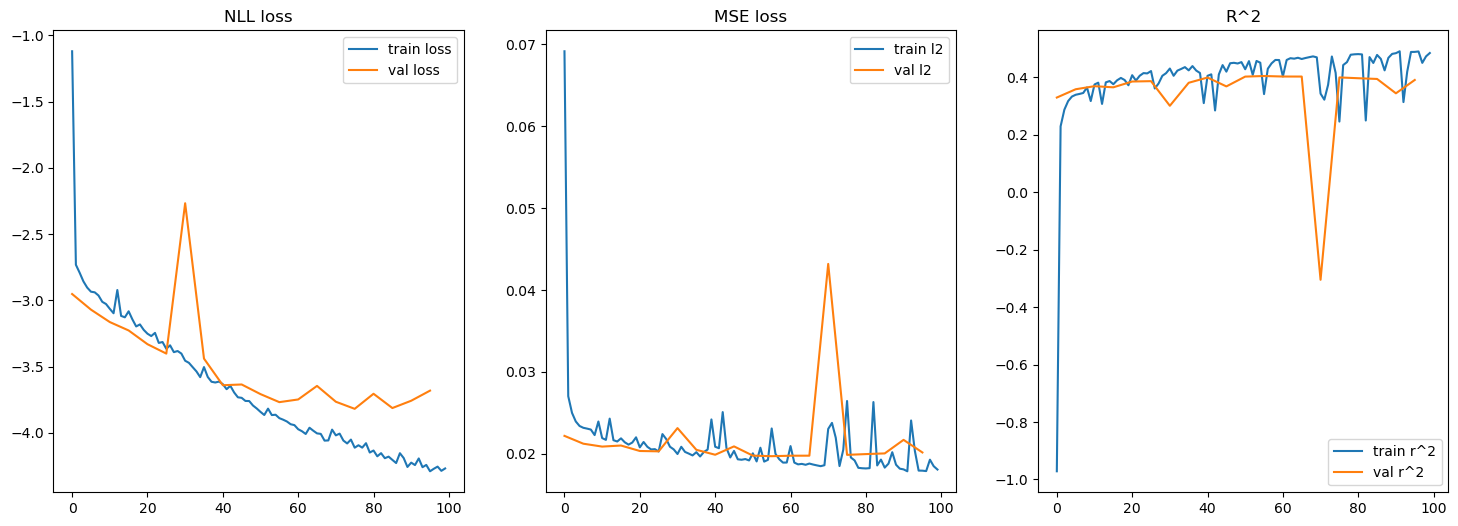

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x_val = np.arange(0, len(trainer.history['loss']), config.val_interval)

plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.plot(trainer.history['loss'], label='train loss')
plt.plot(x_val, trainer.history['val_loss'], label='val loss')
plt.title('NLL loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(trainer.history['l2'], label='train l2')
plt.plot(x_val, trainer.history['val_l2'], label='val l2')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(trainer.history['r^2'], label='train r^2')
plt.plot(x_val, trainer.history['val_r^2'], label='val r^2')
plt.title('R^2')
plt.legend()

In [5]:
def eval(model, dl):
    y_test_all = []
    pred_mean_test_all = []
    pred_sigma_test_all = []
    model.eval()
    with torch.no_grad():
        for batch in dl:

            inp = batch['embeds'].to(config.device)
            label = batch['scores'].to(config.device)

            preds = model(inp)
            
            y_test_all += label.squeeze().detach().cpu().numpy().tolist()
            pred_mean_test_all += preds[:,0].squeeze().detach().cpu().numpy().tolist()
            pred_sigma_test_all += preds[:,1].squeeze().detach().cpu().numpy().tolist()

    y_test_all = np.asarray(y_test_all)
    pred_mean_test_all = np.asarray(pred_mean_test_all)
    pred_sigma_test_all = np.asarray(pred_sigma_test_all)
    pred_sigma_test_all = np.exp(pred_sigma_test_all)
    return y_test_all, pred_mean_test_all, pred_sigma_test_all


train_y, train_pred_mean, train_pred_sigma = eval(model, train_dl)
test_y, test_pred_mean, test_pred_sigma = eval(model, test_dl)


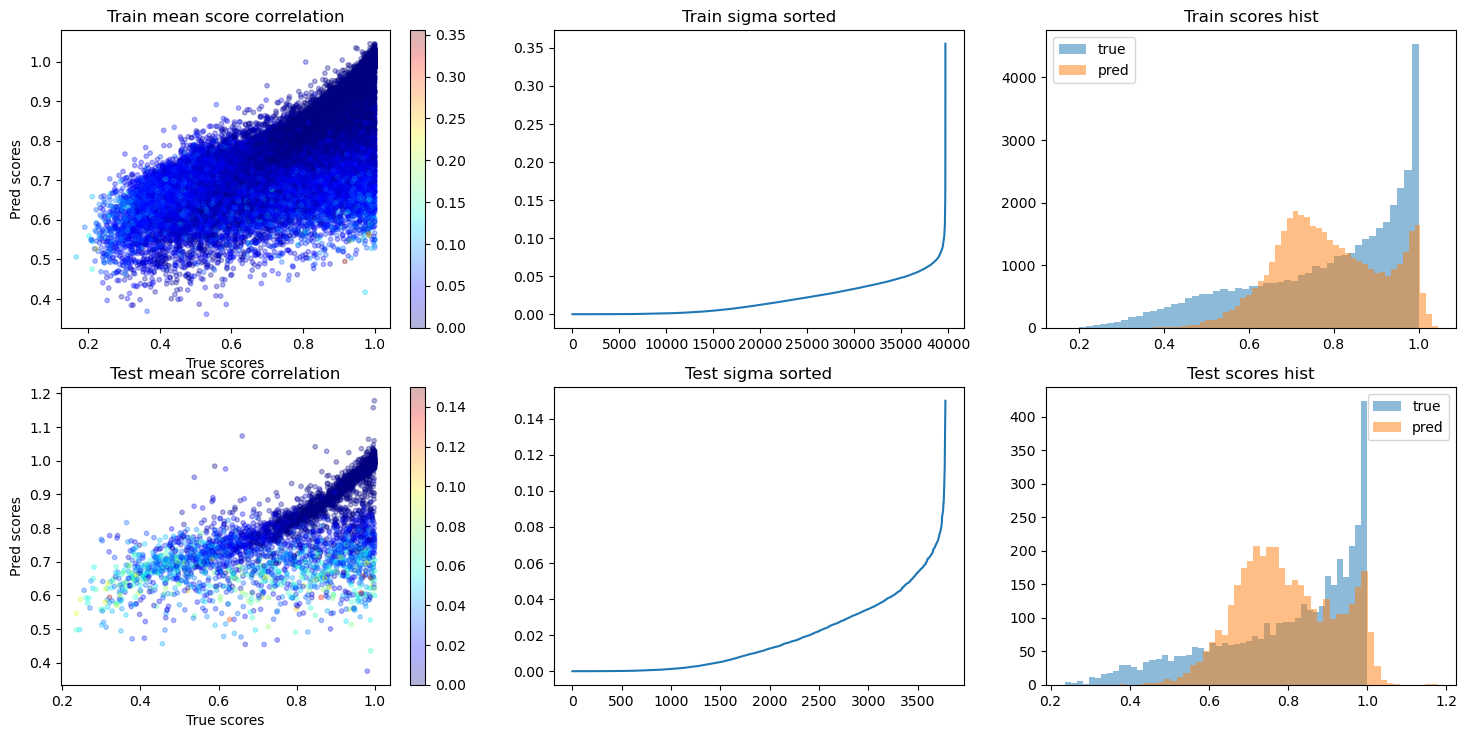

In [6]:
plt.figure(figsize=(18,8.5))

plt.subplot(2,3,1)
hist, edges = np.histogram(train_pred_sigma, bins=50)
hist = hist / hist.sum()
c = np.digitize(train_pred_sigma, edges[1:-1])
c = (c - np.min(c)) / (np.max(c) - np.min(c)) * np.max(train_pred_sigma)
plt.scatter(train_y, train_pred_mean, s=10, alpha=0.3, c=c, cmap='jet')
plt.colorbar()
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Train mean score correlation')

plt.subplot(2,3,2)
plt.plot(sorted(train_pred_sigma))
plt.title('Train sigma sorted')

plt.subplot(2,3,3)
_ = plt.hist(train_y, bins=50, label='true', alpha=0.5)
_ = plt.hist(train_pred_mean, bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Train scores hist')

plt.subplot(2,3,4)
hist, edges = np.histogram(test_pred_sigma, bins=50)
hist = hist / hist.sum()
c = np.digitize(test_pred_sigma, edges[1:-1])
c = (c - np.min(c)) / (np.max(c) - np.min(c)) * np.max(test_pred_sigma)
plt.scatter(test_y, test_pred_mean, s=10, alpha=0.3, c=c, cmap='jet')
plt.colorbar()
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Test mean score correlation')

plt.subplot(2,3,5)
plt.plot(sorted(test_pred_sigma))
plt.title('Test sigma sorted')

plt.subplot(2,3,6)
_ = plt.hist(test_y, bins=50, label='true', alpha=0.5)
_ = plt.hist(test_pred_mean, bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Test scores hist')

plt.show()


## Conformalization

In [24]:
import numpy as np

alpha = 0.1
eps = 1e-6
max_value = 1.0 - eps

def quantize(preds, probs):
    quantize_scores = []
    for prob, pred in zip(probs, preds):
        cumsum = np.sort(prob)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - pred))
        quantize_scores.append(cumsum[ind])
    return np.asarray(quantize_scores)

def calc_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)

    print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                                prediction_sets[np.arange(m), labels].mean()))
    return prediction_sets.sum(1).mean()


In [7]:
# train_predict_out = trainer.predict(model, train_dl)
train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

# max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores'][:,0]
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_true_labels = test_predict_out['cls_labels']
valid_pred_scores = test_predict_out['pred_scores'][:,0]
valid_probs = test_predict_out['cls_probs']

# calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
# valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
# calib_pred_scores = quantize(calib_pred_scores, calib_probs)
# valid_pred_scores = quantize(valid_pred_scores, valid_probs)

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

# diff = diff[np.where(calib_pred_scores<global_qhat)[0]]
n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)
calc_mets(valid_probs, modified_valid_pred_scores, test_predict_out['cls_labels'])


Residuals correction is 0.57718426, clip 26.23% of the samples
mean size 3.563 | acc 0.898


3.562665256478054

# Filter by confidence

In [25]:
def get_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)
    return prediction_sets.sum(1).mean(), prediction_sets[np.arange(m), labels].mean()


use 49.87%/51.96% of the samples
Residuals correction is 0.00000000, clip 1.17% of the samples
use 52.63%/55.47% of the samples
Residuals correction is 0.13915939, clip 8.67% of the samples


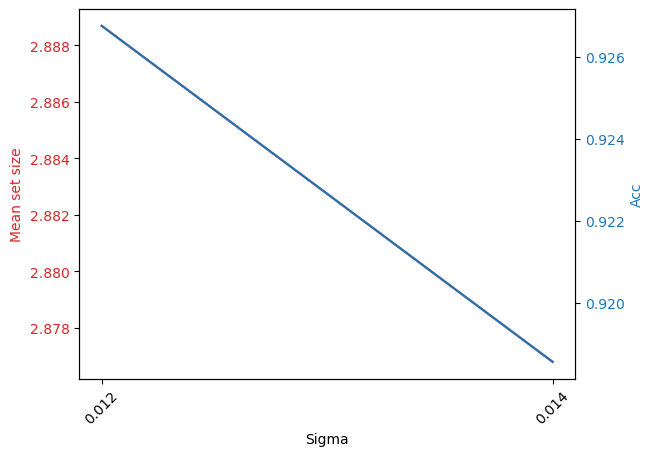

In [32]:
import matplotlib.pyplot as plt

sig2m = {}
sig2acc = {}
sigma_range = np.arange(0.001,0.03,0.001)
# sigma_range = np.asarray([0.005, 0.006, 0.007])
sigma_range = np.asarray([0.012, 0.014])

for sigma_thresh in sigma_range:
    train_predict_out = trainer.predict(model, train_dl)
    # train_predict_out = trainer.predict(model, valid_dl)
    test_predict_out = trainer.predict(model, test_dl)

    # max_value = conformal_module.get_max_value(8)
    calib_pred_sigma = np.exp(train_predict_out['pred_scores'][:,1])
    calib_inds = np.where(calib_pred_sigma<sigma_thresh)[0]

    calib_true_scores = train_predict_out['true_scores'][calib_inds]
    calib_pred_scores = train_predict_out['pred_scores'][calib_inds,0]
    calib_probs = train_predict_out['cls_probs'][calib_inds]

    valid_pred_sigma = np.exp(test_predict_out['pred_scores'][:,1])
    valid_inds = np.where(valid_pred_sigma<sigma_thresh)[0]
    print(f'use {len(calib_inds)/len(calib_pred_sigma)*100:.2f}%/{len(valid_inds)/len(valid_pred_sigma)*100:.2f}% of the samples')

    valid_true_scores = test_predict_out['true_scores'][valid_inds]
    valid_true_labels = test_predict_out['cls_labels'][valid_inds]
    valid_pred_scores = test_predict_out['pred_scores'][valid_inds,0]
    valid_probs = test_predict_out['cls_probs'][valid_inds]

    calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
    valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
    calib_pred_scores = quantize(calib_pred_scores, calib_probs)
    valid_pred_scores = quantize(valid_pred_scores, valid_probs)

    diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
    # diff = calib_true_scores - calib_pred_scores

    # diff = diff[np.where(calib_pred_scores<global_qhat)[0]]
    n = len(diff)
    qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

    modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
    # modified_valid_pred_scores = valid_pred_scores + qhat

    n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
    print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
        qhat, n_over_one * 100.))
    modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)

    scores = np.full_like(test_predict_out['true_scores'], 0.9863331)
    scores[valid_inds] = modified_valid_pred_scores
    m, acc = get_mets(test_predict_out['cls_probs'], scores, test_predict_out['cls_labels'])
    sig2m[sigma_thresh] = m
    sig2acc[sigma_thresh] = acc
    
fig, ax1 = plt.subplots()
x = np.arange(len(sig2acc))

color = 'tab:red'
ax1.set_xlabel('Sigma')
ax1.set_xticks(x, sigma_range.round(4), rotation=45)
ax1.set_ylabel('Mean set size', color=color)
ax1.plot(x, sig2m.values(), color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Acc', color=color)
ax2.plot(x, sig2acc.values(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

In [34]:
k = 0.014
sig2m[k], sig2acc[k]

(2.8767847699629825, 0.9185616076150185)

Text(0.5, 1.0, 'Sigma dist')

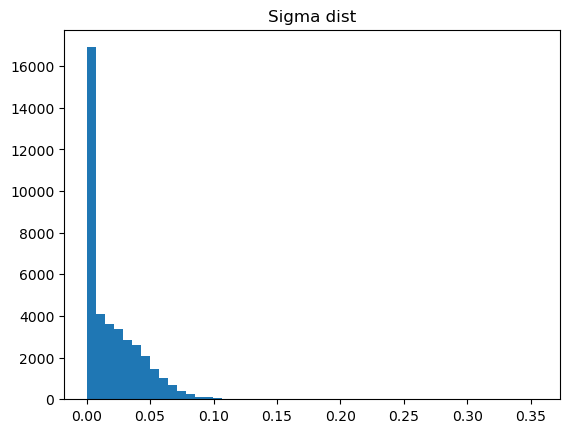

In [31]:
_ = plt.hist(calib_pred_sigma,bins=50)
plt.title('Sigma dist')

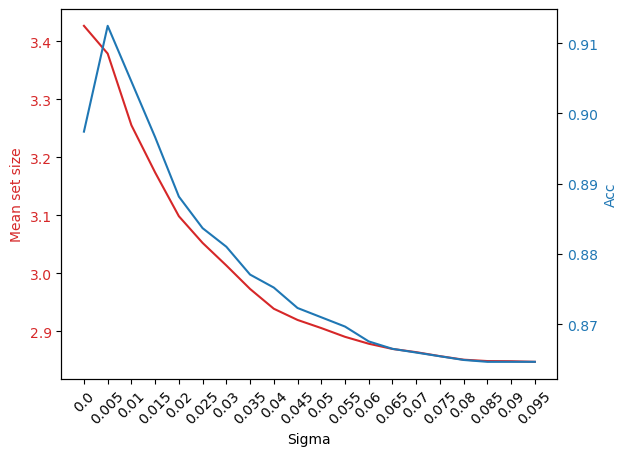

In [43]:
import copy


def get_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)
    return prediction_sets.sum(1).mean(), prediction_sets[np.arange(m), labels].mean()

sig2m = {}
sig2acc = {}
sigma_range = np.arange(0,0.1,0.005)
for sigma_thresh in sigma_range:
    valid_pred_sigma = np.exp(test_predict_out['pred_scores'][:,1])
    inds = np.where(valid_pred_sigma>sigma_thresh)[0]
    # print(f'There are {len(inds)} ({len(inds)/len(valid_pred_sigma)*100:.2f}%) items with sigma above ({sigma_thresh})')
    interleave_valid_scores = copy.deepcopy(modified_valid_pred_scores)
    interleave_valid_scores[inds] = 0.9863331
    m, acc = get_mets(valid_probs, interleave_valid_scores, valid_true_labels)
    sig2m[sigma_thresh] = m
    sig2acc[sigma_thresh] = acc
    
fig, ax1 = plt.subplots()
x = np.arange(len(sig2acc))

color = 'tab:red'
ax1.set_xlabel('Sigma')
ax1.set_xticks(x, sigma_range, rotation=45)
ax1.set_ylabel('Mean set size', color=color)
ax1.plot(x, sig2m.values(), color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Acc', color=color)
ax2.plot(x, sig2acc.values(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()


In [42]:
baseline_mets['aps']

{'size_mean': 3.4865150713907984,
 'size_std': 1.8546333326802822,
 'qhat': 0.9873722,
 'acc': 0.9013749338974087}